In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import requests
from bs4 import BeautifulSoup
import re
import matplotlib.pyplot as plt

# 1. Parameters
window_size = 100
seq_length = 99
embed_size = 128
hidden_size = 256
batch_size = 64
learning_rate = 0.001
num_epochs = 20

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cuda


In [8]:
# 2. Data Preprocessing
def get_data():
    print("Downloading text...")
    url = "https://www.gutenberg.org/cache/epub/84/pg84-images.html"
    response = requests.get(url)
    soup = BeautifulSoup(response.content, 'html.parser')

    text = ""
    for p in soup.find_all("p"):
        t = p.get_text(strip=True)
        if t and len(t) > 30 and not any(x in t.lower() for x in ["project gutenberg", "ebook", "license"]):
            text += t + " "

    text = re.sub(r'\s+', ' ', text).strip().lower()
    words = re.findall(r"\b\w+\b", text)

    words = words[:50000]

    vocab = sorted(list(set(words)))
    word_to_ix = {word: i for i, word in enumerate(vocab)}
    ix_to_word = {i: word for i, word in enumerate(vocab)}

    print(f"Total words: {len(words)}")
    print(f"Unique words (Vocab size): {len(vocab)}")

    inputs = []
    targets = []

    # 99 input, 1 target
    for i in range(len(words) - window_size + 1):
        input_seq = [word_to_ix[w] for w in words[i : i + seq_length]]
        target_word = word_to_ix[words[i + seq_length]]                   # i + 99

        inputs.append(input_seq)
        targets.append(target_word)

    X = torch.LongTensor(inputs)
    y = torch.LongTensor(targets)

    return X, y, len(vocab), word_to_ix, ix_to_word

X, y, vocab_size, word_to_ix, ix_to_word = get_data()
dataset = TensorDataset(X, y)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

Total words: 50000
Unique words (Vocab size): 5853


In [9]:
# 3. Models (RNN / LSTM)
class TextGenRNN(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size):
        super(TextGenRNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.RNN(embed_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        embeds = self.embedding(x)
        out, _ = self.rnn(embeds)
        prediction = self.fc(out[:, -1, :])
        return prediction

class TextGenLSTM(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, num_layers=2):
        super(TextGenLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.lstm = nn.LSTM(embed_size, hidden_size, num_layers, batch_first=True, dropout=0.3)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        embeds = self.embedding(x)
        lstm_out, _ = self.lstm(embeds)
        out = self.fc(lstm_out[:, -1, :])
        return out

In [10]:
# 4. Training
def train_model(model, dataloader, epochs, model_name):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    loss_history = []
    print(f"\n--- Starting training for {model_name} ---")

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for batch_inputs, batch_targets in dataloader:
            batch_inputs, batch_targets = batch_inputs.to(device), batch_targets.to(device)

            optimizer.zero_grad()
            outputs = model(batch_inputs)
            loss = criterion(outputs, batch_targets)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(dataloader)
        loss_history.append(avg_loss)
        print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

    return loss_history


In [11]:
# 5. Text Generation
def generate_text(model, seed_text, generate_length, temperature=0.8):
    model.eval()
    seed_words = re.findall(r"\b\w+\b", seed_text.lower())
    input_seq = [word_to_ix.get(w, 0) for w in seed_words]

    if len(input_seq) < seq_length:
        input_seq = [0] * (seq_length - len(input_seq)) + input_seq

    input_seq = input_seq[-seq_length:]
    generated_text = seed_words[:]

    with torch.no_grad():
        for _ in range(generate_length):
            x = torch.LongTensor([input_seq]).to(device)
            output = model(x)

            probs = torch.softmax(output[0] / temperature, dim=0).cpu().numpy()
            next_ix = np.random.choice(len(probs), p=probs)
            next_word = ix_to_word[next_ix]

            generated_text.append(next_word)

            # Sliding window
            input_seq.append(next_ix)
            input_seq = input_seq[1:]

    return " ".join(generated_text)



--- Starting training for RNN ---
Epoch 1/20, Loss: 6.3890
Epoch 2/20, Loss: 5.4731
Epoch 3/20, Loss: 4.8270
Epoch 4/20, Loss: 4.2120
Epoch 5/20, Loss: 3.6292
Epoch 6/20, Loss: 3.1086
Epoch 7/20, Loss: 2.6599
Epoch 8/20, Loss: 2.2755
Epoch 9/20, Loss: 1.9564
Epoch 10/20, Loss: 1.6826
Epoch 11/20, Loss: 1.4527
Epoch 12/20, Loss: 1.2547
Epoch 13/20, Loss: 1.0893
Epoch 14/20, Loss: 0.9408
Epoch 15/20, Loss: 0.8228
Epoch 16/20, Loss: 0.7149
Epoch 17/20, Loss: 0.6285
Epoch 18/20, Loss: 0.5525
Epoch 19/20, Loss: 0.4872
Epoch 20/20, Loss: 0.4328

--- Starting training for LSTM ---
Epoch 1/20, Loss: 6.5542
Epoch 2/20, Loss: 5.9817
Epoch 3/20, Loss: 5.6584
Epoch 4/20, Loss: 5.3959
Epoch 5/20, Loss: 5.1389
Epoch 6/20, Loss: 4.8762
Epoch 7/20, Loss: 4.5953
Epoch 8/20, Loss: 4.3079
Epoch 9/20, Loss: 4.0216
Epoch 10/20, Loss: 3.7527
Epoch 11/20, Loss: 3.4894
Epoch 12/20, Loss: 3.2449
Epoch 13/20, Loss: 3.0138
Epoch 14/20, Loss: 2.8093
Epoch 15/20, Loss: 2.6207
Epoch 16/20, Loss: 2.4426
Epoch 17/20

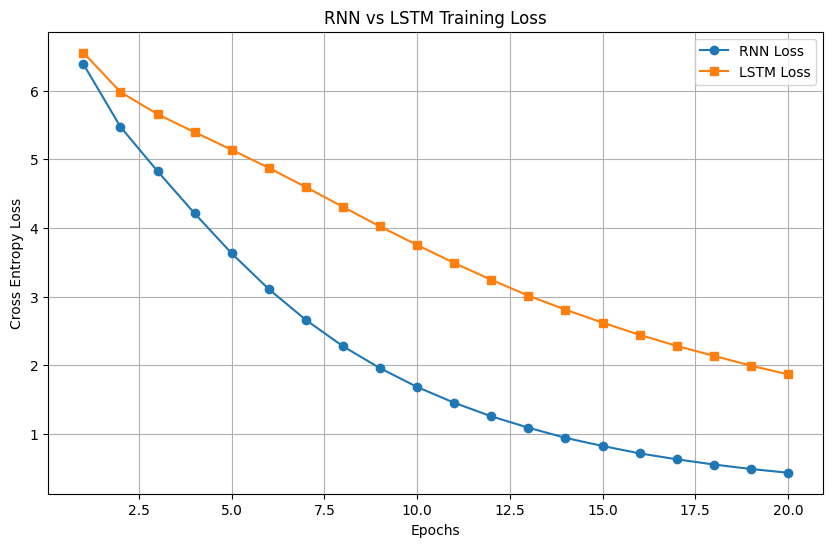


 RNN Generated Text:
you will rejoice to hear that no disaster has accompanied the commencement of an enterprise town to my marriage we have already reached a very high latitude but it is the height of summer and although not so warm as to believe myself for the trial of one of this i was not then i heard of the cottagers this was so guided by the sun and i made myself under the shade of the old man paused i resolved to relieve home and kept nor many months calm and that i should be reserved to discover so astonishing a secret remember i am not recording the vision of a madman i lay down among

 LSTM Generated Text:
you will rejoice to hear that no disaster has accompanied the commencement of an enterprise which i had so wantonly bestowed justine was the murderer of your dead father restore themselves on yourself from whom he had retired to a corner of crime when he came with this place that she has permitted me to procure and dismissed me alone rest we shall there hear him and joyous

In [12]:
# 6. Comparison
if __name__ == "__main__":
    rnn_model = TextGenRNN(vocab_size, embed_size, hidden_size).to(device)
    lstm_model = TextGenLSTM(vocab_size, embed_size, hidden_size).to(device)

    rnn_losses = train_model(rnn_model, dataloader, num_epochs, "RNN")
    lstm_losses = train_model(lstm_model, dataloader, num_epochs, "LSTM")

    plt.figure(figsize=(10, 6))
    plt.plot(range(1, num_epochs+1), rnn_losses, label='RNN Loss', marker='o')
    plt.plot(range(1, num_epochs+1), lstm_losses, label='LSTM Loss', marker='s')
    plt.title('RNN vs LSTM Training Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Cross Entropy Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

    seed_sentence = "you will rejoice to hear that no disaster has accompanied the commencement of an enterprise"

    print("\n" + "="*80)
    print(" RNN Generated Text:")
    print("="*80)
    print(generate_text(rnn_model, seed_sentence, 100))

    print("\n" + "="*80)
    print(" LSTM Generated Text:")
    print("="*80)
    print(generate_text(lstm_model, seed_sentence, 100))